# Palace Differential GSGSG Simulation — Wave Ports

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook is the differential counterpart to [palace_cpw_waveport.ipynb](./palace_cpw_waveport.ipynb): instead of a single-ended GSG coplanar waveguide it drives a **GSGSG** structure — two signal electrodes sharing a central ground — and extracts the **differential** and **common-mode** impedance and effective index.

The two signal electrodes sit on an 80 µm pitch, far enough apart that each behaves as its own CPW. That decoupling is what makes the port scheme below possible: rather than one wave port spanning the whole boundary face, each signal line gets **its own wave port** covering only its share of the width. Four ports (two per face) then give a full 4×4 single-ended S-matrix, which converts to mixed-mode parameters with `scikit-rf`.

A follow-up section loads the line with **T-bars** — the periodic capacitive loading an MZM modulator segment presents to a travelling-wave electrode — and shows how that lowers $Z_c$ and raises $n_{\mathrm{eff}}$.

**Requirements:**

- IHP PDK: `uv pip install ihp-gdsfactory`
- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Define GSGSG electrode

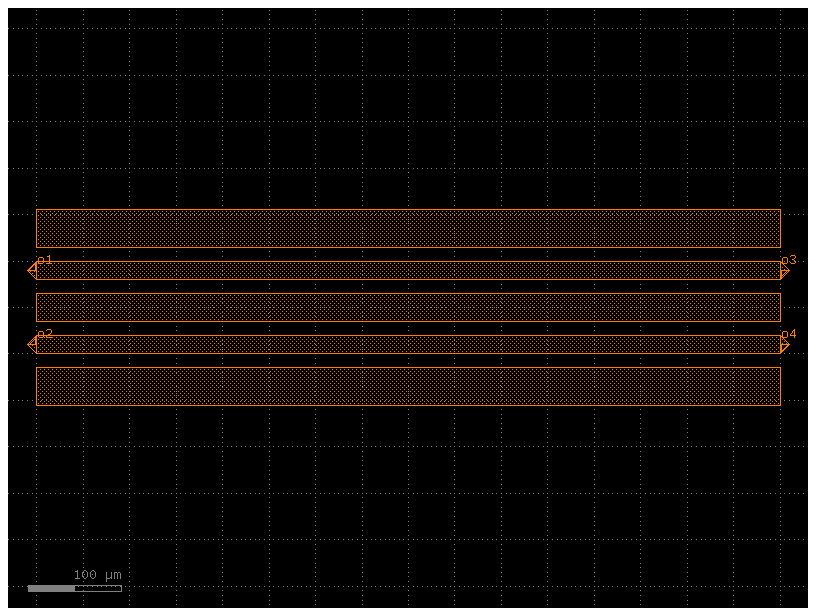

In [1]:
import gdsfactory as gf
from ihp import LAYER, PDK

PDK.activate()


@gf.cell
def gsgsg_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    signal_pitch: float = 80,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    Create a GSGSG (differential coplanar) electrode.

    The two signal electrodes sit on `signal_pitch` centres, separated by a
    shared central ground, so each line is its own CPW and the two are only
    weakly coupled.

    Args:
        length: horizontal length of the electrodes
        s_width: width of each signal electrode
        g_width: width of the two outer ground electrodes
        gap_width: gap between a signal electrode and its adjacent grounds
        signal_pitch: centre-to-centre spacing of the two signal electrodes
        layer: layer for the metal
    """
    c = gf.Component()

    center_g_width = signal_pitch - s_width - 2 * gap_width
    if center_g_width <= 0:
        raise ValueError(
            f"signal_pitch={signal_pitch} is too small for s_width={s_width} "
            f"and gap_width={gap_width}: the central ground would vanish."
        )

    s_center = signal_pitch / 2
    g_center = s_center + s_width / 2 + gap_width + g_width / 2

    # Central ground, shared by both lines
    c << gf.c.rectangle((length, center_g_width), centered=True, layer=layer)

    for sign in (+1, -1):
        sig = c << gf.c.rectangle((length, s_width), centered=True, layer=layer)
        sig.move((0, sign * s_center))

        gnd = c << gf.c.rectangle((length, g_width), centered=True, layer=layer)
        gnd.move((0, sign * g_center))

    # Port order matters: scikit-rf se2gmm(p=2) treats ports (0, 1) as the
    # left-hand pair and (2, 3) as the right-hand pair, with 0-2 and 1-3 the
    # two through paths. So: o1/o3 = upper line, o2/o4 = lower line.
    for name, x, orientation, sign in (
        ("o1", -length / 2, 180, +1),
        ("o2", -length / 2, 180, -1),
        ("o3", length / 2, 0, +1),
        ("o4", length / 2, 0, -1),
    ):
        c.add_port(
            name=name,
            center=(x, sign * s_center),
            width=s_width,
            orientation=orientation,
            port_type="electrical",
            layer=layer,
        )

    c.info["s_width"] = s_width
    c.info["g_width"] = g_width
    c.info["gap_width"] = gap_width
    c.info["signal_pitch"] = signal_pitch
    c.info["center_g_width"] = center_g_width
    return c


c = gsgsg_electrode()
cc = c.copy()
cc.draw_ports()
cc

### Configure simulation

Each signal line gets its own wave port, so the port rectangles must **not** span the full boundary face — `max_size=True` would make the two ports on a face identical and overlapping. Two settings control the extent instead:

- **`lateral_margin`** sets the half-width of the port box around the signal centre. At 25 µm the box spans $y \in [5, 75]$ for the upper line, so its edges land ~10 µm inside the central ground and ~10 µm inside the outer ground, where the fields are already small. Palace treats the port cross-section boundary as PEC in the port eigenproblem, and terminating it inside a ground conductor is a good approximation of that. The two boxes on a face are left 10 µm apart.
- **`full_height=True`** makes the port span the simulation domain in $z$. This matters: the air box is not part of the layer stack, so without it the port box is clamped to the stack and collapses onto the conductor itself, putting a PEC lid directly above the electrodes and badly corrupting $Z_c$ and $n_{\mathrm{eff}}$.

**All four ports are excited.** Palace assigns one excitation index per excited port, and the results parser fills missing S-matrix entries only by reciprocity — never by geometric symmetry. Exciting fewer ports would leave whole rows of the 4×4 at exactly zero, and the mixed-mode transform needs the complete matrix. Four excitations is ~4× the solve cost of the single-ended notebook, which is why the sweep is 1–50 GHz with 100 points.

In [2]:
from gsim.common.stack import get_stack
from gsim.palace import DrivenSim

PORT_NAMES = ("o1", "o2", "o3", "o4")


def setup_sim(cell, output_dir="./palace-sim-gsgsg-waveport"):
    sim = DrivenSim()
    sim.set_output_dir(output_dir)
    sim.set_geometry(cell)

    stack = get_stack()  # auto-detects active PDK
    sim.set_stack(stack)
    sim.set_airbox(margin_x=0.0, margin_y=50, z_above=100.0, z_below=100.0)

    # One wave port per signal line per face. Partial width (so the two ports
    # on a face do not overlap) but full height in z.
    lateral_margin = cell.info["gap_width"] + cell.info["g_width"] / 4

    for name in PORT_NAMES:
        sim.add_wave_port(
            name,
            layer="topmetal2",
            lateral_margin=lateral_margin,
            full_height=True,
            mode=1,
            excited=True,
        )

    sim.set_driven(fmin=1e9, fmax=50e9, num_points=100)

    print(sim.validate_config())

    return sim


sim = setup_sim(c)

Validation: PASSED


### Generate mesh

In [3]:
sim.mesh(preset="default", refined_mesh_size=2.0, max_mesh_size=40.0, fmax=60e9)

Mesh Summary
Dimensions: 800.0 x 410.0 x 217.9 µm
Nodes:      53,024
Elements:   391,187
Tetrahedra: 288,107
Edge length: 1.13 - 84.00 µm
Quality:    0.633 (min: 0.005)
SICN:       0.683 (all valid)
----------------------------------------
Volumes (3):
  - sio2 [1]
  - sin [2]
  - air [3]
Surfaces (12):
  - topmetal2_xy [4]
  - topmetal2_z [5]
  - P1 [6]
  - P2 [7]
  - P3 [8]
  - P4 [9]
  - sio2__None [10]
  - air__sio2 [11]
  - sin__sio2 [12]
  - sin__None [13]
  - air__sin [14]
  - air__None [15]
----------------------------------------
Mesh:   palace-sim-gsgsg-waveport/palace.msh

In [4]:
# Confirm the four port boxes are partial-width, full-height and non-overlapping
for p in sim._last_mesh_result.port_info:
    print(
        f"P{p['portnumber']}  x={p['xmin']:7.1f}  "
        f"y=[{p['ymin']:6.1f}, {p['ymax']:6.1f}]  "
        f"z=[{p['zmin']:7.1f}, {p['zmax']:7.1f}]"
    )

P1  x= -400.0  y=[   5.0,   75.0]  z=[ -102.0,   115.9]
P2  x= -400.0  y=[ -75.0,   -5.0]  z=[ -102.0,   115.9]
P3  x=  400.0  y=[   5.0,   75.0]  z=[ -102.0,   115.9]
P4  x=  400.0  y=[ -75.0,   -5.0]  z=[ -102.0,   115.9]


In [5]:
sim.plot_mesh(
    style="solid",
    transparent_groups=["air__None", "SiO2__None", "SiO2__passive", "air__passive"],
    interactive=True,
)

Widget(value='<iframe src="http://localhost:36321/index.html?ui=P_0x7c3a0c844a70_0&reconnect=auto" class="pyvi…

### Run simulation

In [6]:
results = sim.run(check_cache=True)

  palace-bee9df92  [####################] 100%  complete  elapsed 17m 41s
Extracting results.tar.gz...
Downloaded 9 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-bee9df92


In [7]:
results.plot_interactive()

Port mapping: Port 1: o1, Port 2: o2, Port 3: o3, Port 4: o4


## Differential and common-mode parameters

The 4×4 single-ended S-matrix converts to mixed-mode parameters with `scikit-rf`'s `se2gmm`. For a 4-port it assumes ports (0, 1) are the left-hand pair and (2, 3) the right-hand pair, and returns port 0 = differential left, 1 = differential right, 2 = common left, 3 = common right — hence the `o1`/`o2`/`o3`/`o4` ordering chosen in the geometry cell. Reference impedances become $2 z_0$ differential and $z_0/2$ common.

$Z_c$ and $\gamma$ then come from the ABCD matrix of each mode's 2-port. For a uniform, symmetric, reciprocal line

$$\mathrm{ABCD} = \begin{bmatrix} \cosh \gamma \ell & Z_c \sinh \gamma \ell \\ \sinh \gamma \ell / Z_c & \cosh \gamma \ell \end{bmatrix}$$

so $Z_c = \sqrt{B/C}$, and fixing that square root on the passive ($\mathrm{Re} > 0$) branch makes $\sinh \gamma\ell = B / Z_c$ unambiguous too. Then $e^{\gamma \ell} = \cosh \gamma\ell + \sinh \gamma\ell$ is fully determined and $\gamma \ell$ follows from its complex logarithm, with only the $2\pi$ of the phase left to unwrap over the sweep.

This differs from the eigenvector/eigenvalue approach used in the single-ended notebook, and deliberately so. Selecting the forward ABCD eigenvalue is only unambiguous while $|\beta \ell| < \pi$. Beyond that the two eigenvalues $e^{\pm j \beta \ell}$ of a low-loss line do not cross but **collide** at $\beta\ell = \pi$, so neither picking the most-negative phase nor tracking by continuity can stay on the forward wave — both silently return a wrong $n_{\mathrm{eff}}$. The T-bar section below pushes $n_{\mathrm{eff}}$ high enough for an 800 µm line to cross that threshold within this sweep. On two synthetic uncoupled 50 Ω lines with $n_{\mathrm{eff}} = 2$, the formulation used here recovers $Z_c$ = 50/100/25 Ω and $n_{\mathrm{eff}} = 2$ to machine precision out past $\beta\ell = 2\pi$, where the eigenvalue methods return 1.73.

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf
from scipy.constants import speed_of_light
from skrf.calibration.deembedding import IEEEP370_SE_NZC_2xThru


def _positive_real_branch(z):
    return np.where(np.real(z) < 0, -z, z)


def extract_modal_parameters(net, length_m):
    """Return Zc, gamma and neff of a uniform symmetric 2-port from its ABCD.

    Branch-free: Zc = sqrt(B/C) on the passive branch determines
    sinh(gamma*l) = B/Zc, hence exp(gamma*l) = cosh + sinh, leaving only the
    2*pi of the complex log to unwrap. No eigenvalue selection, so the
    beta*l = pi eigenvalue collision of a low-loss line never arises.
    """
    a = net.a
    A, B, C, D = a[:, 0, 0], a[:, 0, 1], a[:, 1, 0], a[:, 1, 1]

    zc = _positive_real_branch(np.sqrt(B / C))
    cosh_gl = (A + D) / 2
    sinh_gl = B / zc
    exp_gl = cosh_gl + sinh_gl

    gamma_l = np.log(np.abs(exp_gl)) + 1j * np.unwrap(np.angle(exp_gl))
    gamma = gamma_l / length_m

    neff = np.full(len(net), np.nan)
    nonzero = net.f != 0
    neff[nonzero] = (
        np.imag(gamma[nonzero]) * speed_of_light / (2 * np.pi * net.f[nonzero])
    )

    # Reciprocity/symmetry residual: a uniform line has A == D and AD - BC == 1.
    symmetry_error = np.max(np.abs(A - D) / np.maximum(np.abs(A), 1e-30))

    return {
        "zc": zc,
        "gamma": gamma,
        "neff": neff,
        "symmetry_error": symmetry_error,
    }


def to_mixed_mode(sparams):
    """Split a 4-port GSGSG result into single-ended, differential and common 2-ports."""
    net = sparams.to_skrf()
    net.frequency.unit = "GHz"

    # Port order comes from the results parser, not from the add_wave_port call
    # order, and se2gmm's pairing convention depends on it. A stale cached run
    # (pre-dating named ports) falls back to p1..pN instead of o1..o4; those
    # are already in add_wave_port call order, so there is nothing to reorder.
    names = list(sparams.port_names)
    if len(names) != len(PORT_NAMES):
        raise ValueError(
            f"Expected {len(PORT_NAMES)} ports, got {names} — cannot infer "
            "mixed-mode pairing."
        )
    if set(names) >= set(PORT_NAMES):
        if names != list(PORT_NAMES):
            net.renumber([names.index(n) for n in PORT_NAMES], range(len(PORT_NAMES)))
    elif not all(n.startswith("p") and n[1:].isdigit() for n in names):
        raise ValueError(
            f"Port names {names} are neither {list(PORT_NAMES)} nor the "
            "numeric fallback (p1, p2, ...) — cannot infer mixed-mode pairing."
        )

    net_mm = net.copy()
    net_mm.se2gmm(p=2)

    z0 = np.real(net.z0[0, 0])
    assert np.allclose(np.real(net_mm.z0[0, :2]), 2 * z0), net_mm.z0[0]
    assert np.allclose(np.real(net_mm.z0[0, 2:]), z0 / 2), net_mm.z0[0]

    return {
        "single": net.subnetwork([0, 2]),  # upper line, left -> right
        "diff": net_mm.subnetwork([0, 1]),
        "comm": net_mm.subnetwork([2, 3]),
        "se": net,
        "mm": net_mm,
    }


def p370_extract(short_2xthru, long_fix_dut_fix, delta_length_m):
    """Extract the additional DUT length using a mirrored IEEE P370 split."""
    reference_z0 = float(np.real(np.median(short_2xthru.z0[:, 0])))
    deembedding = IEEEP370_SE_NZC_2xThru(
        dummy_2xthru=short_2xthru,
        z0=reference_z0,
        use_z_instead_ifft=True,
        name="100 um non-zero-length 2xThru",
    )
    dut = deembedding.deembed(long_fix_dut_fix)

    # Explicitly reconstruct both topologies to check fixture orientation.
    reconstructed_short = deembedding.s_side1 ** deembedding.s_side2.flipped()
    reconstructed_long = deembedding.s_side1**dut ** deembedding.s_side2.flipped()
    result = extract_modal_parameters(dut, delta_length_m)
    result.update(
        {
            "dut": dut,
            "deembedding": deembedding,
            "split_error": np.max(np.abs(reconstructed_short.s - short_2xthru.s)),
            "reembed_error": np.max(np.abs(reconstructed_long.s - long_fix_dut_fix.s)),
        }
    )
    return result

In [9]:
nets = to_mixed_mode(results)

LENGTH_M = 800e-6
modes = {
    k: extract_modal_parameters(nets[k], LENGTH_M) for k in ("single", "diff", "comm")
}

for label, m in modes.items():
    print(
        f"{label:7s} Zc = {np.median(m['zc'].real):7.2f} ohm   "
        f"neff = {np.nanmedian(m['neff']):6.3f}   "
        f"A-D asymmetry = {m['symmetry_error']:.2e}"
    )

beta_l = 2 * np.pi * nets["diff"].f * np.nanmedian(modes["diff"]["neff"]) * LENGTH_M
print(f"\nmax |beta*l| over the sweep = {beta_l.max() / speed_of_light:.2f} rad")

single  Zc =   54.51 ohm   neff =  1.762   A-D asymmetry = 6.51e-05
diff    Zc =  105.34 ohm   neff =  1.727   A-D asymmetry = 2.94e-04
comm    Zc =   28.34 ohm   neff =  1.804   A-D asymmetry = 2.08e-04

max |beta*l| over the sweep = 1.45 rad


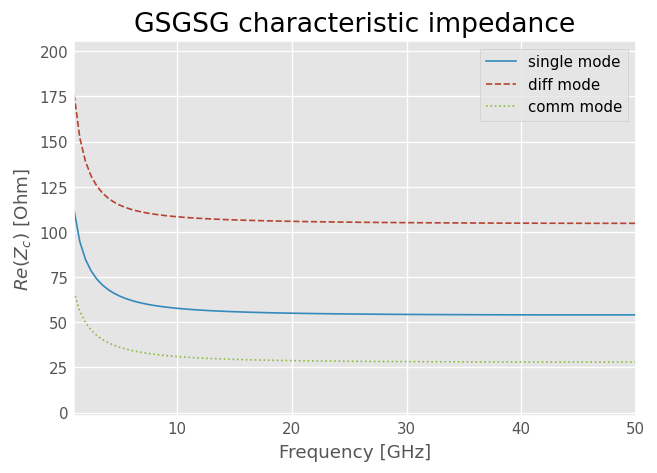

In [10]:
rf.stylely()

fig, ax = plt.subplots()
for label, style in (("single", "-"), ("diff", "--"), ("comm", ":")):
    ax.plot(
        nets[label].frequency.f_scaled,
        modes[label]["zc"].real,
        style,
        label=f"{label} mode",
    )
ax.set_xlabel(f"Frequency [{nets['diff'].frequency.unit}]")
ax.set_ylabel(r"$Re(Z_c)$ [Ohm]")
ax.set_title("GSGSG characteristic impedance")
ax.legend()

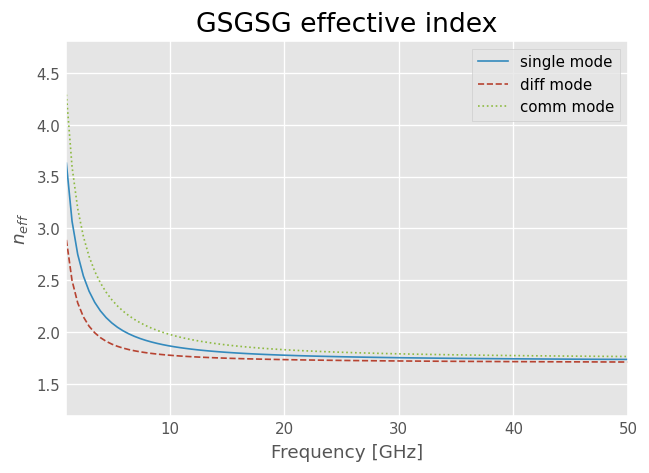

In [11]:
fig, ax = plt.subplots()
for label, style in (("single", "-"), ("diff", "--"), ("comm", ":")):
    ax.plot(
        nets[label].frequency.f_scaled,
        modes[label]["neff"].real,
        style,
        label=f"{label} mode",
    )
ax.set_xlabel(f"Frequency [{nets['diff'].frequency.unit}]")
ax.set_ylabel(r"$n_{eff}$")
ax.set_title("GSGSG effective index")
ax.legend()

### How decoupled are the two lines?

At an 80 µm pitch the two lines are decoupled *by construction*, which means the mixed-mode transform is close to a pure rescaling: an ideal pair of independent lines has exactly $Z_{c,\mathrm{diff}} = 2 Z_{c,\mathrm{single}}$, $Z_{c,\mathrm{comm}} = Z_{c,\mathrm{single}}/2$ and $n_{\mathrm{eff,diff}} = n_{\mathrm{eff,comm}}$. The informative quantity is therefore not the mixed-mode values themselves but the **departure** from those identities, which measures the residual coupling directly:

- $Z_{c,\mathrm{diff}} / (2 Z_{c,\mathrm{single}}) - 1$ — deviates below zero as the lines couple
- $n_{\mathrm{eff,diff}} - n_{\mathrm{eff,comm}}$ — zero only for truly independent lines
- $|S_{dc}|$ — differential-to-common **mode conversion**
- $|S_{21}|$ between the two left-hand ports — direct near-end crosstalk

The mode-conversion term carries extra weight because the analysis above slices the mixed-mode matrix as `subnetwork([0, 1])` and `subnetwork([2, 3])`, which treats the differential and common modes as two independent 2-ports. That is only legitimate while $S_{dc} \approx S_{cd} \approx 0$; the symmetry of this structure should make it so, but it is an assumption worth confirming rather than presuming. It matters most in the T-bar section, where the shared central ground genuinely couples the two lines.

max |Sdc| = 5.844e-05
max near-end crosstalk = -27.4 dB


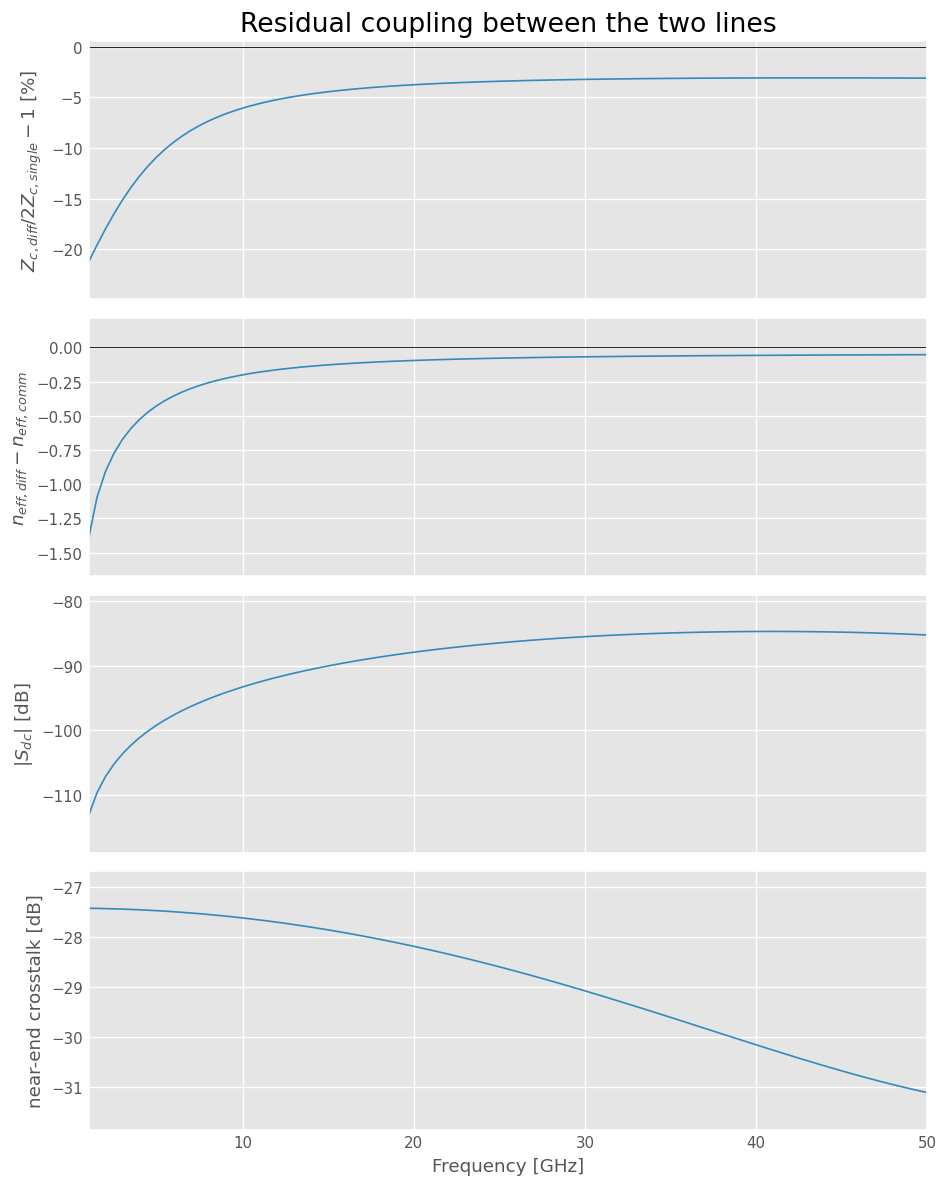

In [12]:
fig, axes = plt.subplots(nrows=4, sharex=True, figsize=(8, 10))
freq_scaled = nets["diff"].frequency.f_scaled
unit = nets["diff"].frequency.unit

zc_ratio = modes["diff"]["zc"].real / (2 * modes["single"]["zc"].real) - 1
axes[0].plot(freq_scaled, 100 * zc_ratio)
axes[0].set_ylabel(r"$Z_{c,diff} / 2Z_{c,single} - 1$ [%]")
axes[0].axhline(0, color="k", lw=0.5)

axes[1].plot(freq_scaled, modes["diff"]["neff"].real - modes["comm"]["neff"].real)
axes[1].set_ylabel(r"$n_{eff,diff} - n_{eff,comm}$")
axes[1].axhline(0, color="k", lw=0.5)

# Mode conversion. Slicing the mixed-mode matrix into independent differential
# and common 2-ports is only valid while these stay small.
s_mm = nets["mm"].s
mode_conversion = np.maximum(np.abs(s_mm[:, 0, 2]), np.abs(s_mm[:, 2, 0]))
axes[2].plot(freq_scaled, 20 * np.log10(np.maximum(mode_conversion, 1e-20)))
axes[2].set_ylabel(r"$|S_{dc}|$ [dB]")

# Near-end crosstalk: port 2 (lower line, left) driven from port 1 (upper, left)
axes[3].plot(freq_scaled, 20 * np.log10(np.abs(nets["se"].s[:, 1, 0])))
axes[3].set_ylabel("near-end crosstalk [dB]")
axes[3].set_xlabel(f"Frequency [{unit}]")

axes[0].set_title("Residual coupling between the two lines")
plt.tight_layout()

print(f"max |Sdc| = {mode_conversion.max():.3e}")
print(
    f"max near-end crosstalk = {20 * np.log10(np.abs(nets['se'].s[:, 1, 0])).max():.1f} dB"
)

## Length verification

Three GSGSG electrodes (100, 400, 800 µm) are simulated under identical waveport and mesh settings. The 100 µm line is used as an <a href="https://scikit-rf.readthedocs.io/en/latest/api/calibration/generated/skrf.calibration.deembedding.IEEEP370_SE_NZC_2xThru.html">IEEE P370 NZC 2x-thru fixture</a> and de-embedded from the longer results to yield effective 300 µm (400−100) and 700 µm (800−100) DUT segments.

As in the single-ended notebook, the purpose is to see how much the port parasitics perturb the extracted parameters: the waveport boundary introduces a reactive discontinuity at each end whose magnitude is fixed regardless of line length, so the shortest line carries the largest fractional contamination and should deviate most. Here the de-embedding is applied **separately to the differential and common-mode 2-ports**, each of which is an ordinary 2-port that the P370 fixture handles directly.

In [13]:
gsgsg100 = gsgsg_electrode(length=100)
gsgsg400 = gsgsg_electrode(length=400)
gsgsg800 = gsgsg_electrode(length=800)

In [14]:
raw_results = []
for lc in [gsgsg100, gsgsg400, gsgsg800]:
    sim = setup_sim(lc)
    sim.mesh(preset="default", refined_mesh_size=2.0, max_mesh_size=40.0, fmax=60e9)
    raw_results.append(sim.run(wait=False, check_cache=True))

Validation: PASSED
Job started: palace-0fb79955
Validation: PASSED
Job started: palace-4f0b08d5
Validation: PASSED
Cache hit: reusing job 01a0d372-4455-7b80-9f21-7bca0e53f845


In [15]:
import gsim

# Poll all jobs concurrently, download and parse results
raw_results = gsim.wait_for_results(raw_results)

Waiting for 3 jobs...
  palace-0fb79955                [####################] 100% complete     elapsed 5m 42s
  palace-4f0b08d5                [####################] 100% complete     elapsed 11m 36s
  palace-bee9df92                [####################] 100% complete     elapsed 0m 00s
Extracting results.tar.gz...
Downloaded 9 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-0fb79955
Extracting results.tar.gz...
Downloaded 9 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-4f0b08d5
Extracting results.tar.gz...
Downloaded 9 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-bee9df92


In [16]:
mm = [to_mixed_mode(r) for r in raw_results]

# De-embed the 100 um fixture from the 400 and 800 um lines, per mode
deembedded = {}
for mode in ("single", "diff", "comm"):
    deembedded[mode] = {
        300: p370_extract(mm[0][mode], mm[1][mode], delta_length_m=300e-6),
        700: p370_extract(mm[0][mode], mm[2][mode], delta_length_m=700e-6),
    }

for mode, lengths in deembedded.items():
    for length_um, res in lengths.items():
        print(
            f"{mode:7s} {length_um:3d} um   split_error={res['split_error']:.2e}   "
            f"reembed_error={res['reembed_error']:.2e}"
        )

single  300 um   split_error=2.18e-07   reembed_error=9.31e-16
single  700 um   split_error=2.18e-07   reembed_error=7.85e-16
diff    300 um   split_error=2.26e-07   reembed_error=7.83e-16
diff    700 um   split_error=2.26e-07   reembed_error=8.25e-16
comm    300 um   split_error=2.11e-07   reembed_error=8.01e-16
comm    700 um   split_error=2.11e-07   reembed_error=8.08e-16


In [17]:
direct = {
    mode: {
        100: extract_modal_parameters(mm[0][mode], 100e-6),
        400: extract_modal_parameters(mm[1][mode], 400e-6),
        800: extract_modal_parameters(mm[2][mode], 800e-6),
    }
    for mode in ("single", "diff", "comm")
}

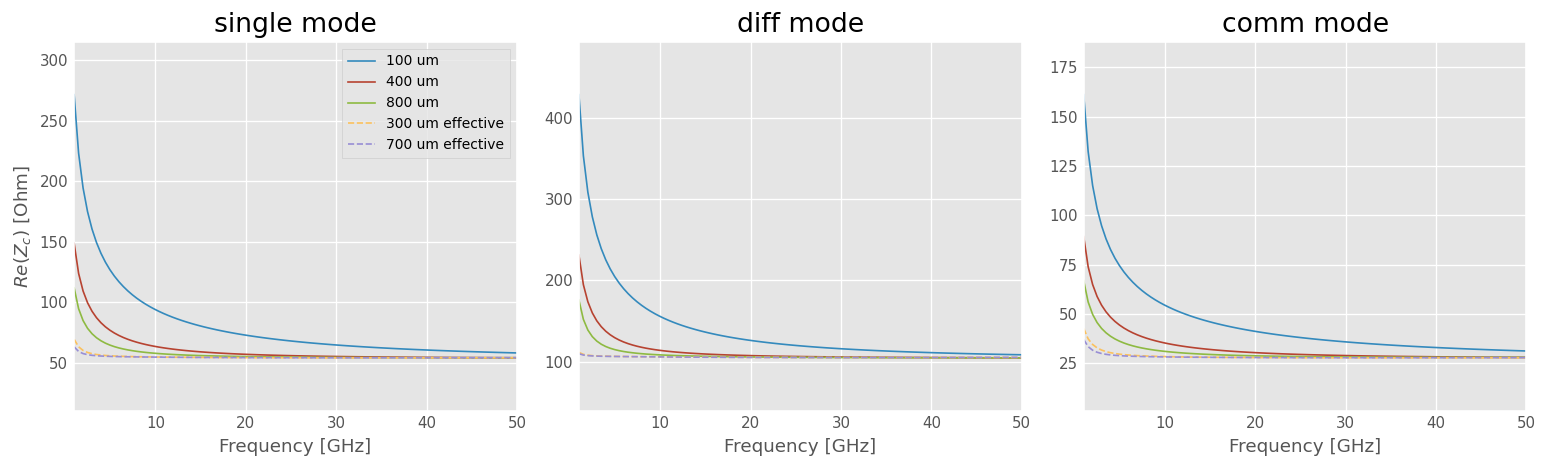

In [18]:
fig, axes = plt.subplots(ncols=3, sharex=True, figsize=(13, 4))

for ax, mode in zip(axes, ("single", "diff", "comm"), strict=True):
    freq_scaled = mm[0][mode].frequency.f_scaled
    for length_um in (100, 400, 800):
        ax.plot(
            freq_scaled, direct[mode][length_um]["zc"].real, label=f"{length_um} um"
        )
    for length_um in (300, 700):
        ax.plot(
            freq_scaled,
            deembedded[mode][length_um]["zc"].real,
            "--",
            label=f"{length_um} um effective",
        )
    ax.set_title(f"{mode} mode")
    ax.set_xlabel(f"Frequency [{mm[0][mode].frequency.unit}]")

axes[0].set_ylabel(r"$Re(Z_c)$ [Ohm]")
axes[0].legend(fontsize="small")
plt.tight_layout()

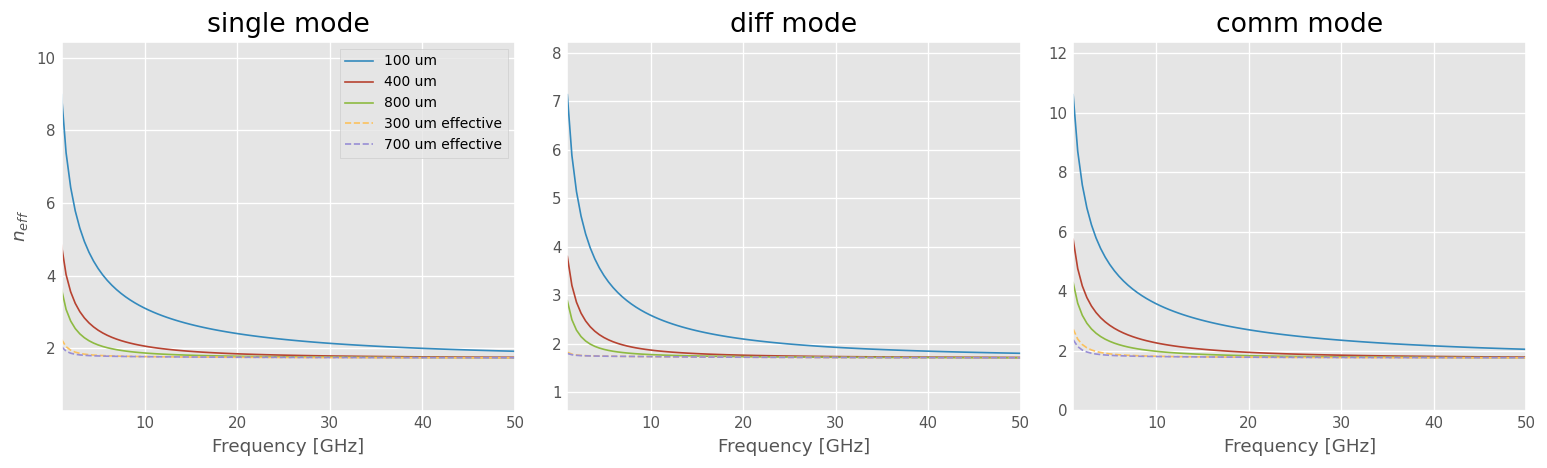

In [19]:
fig, axes = plt.subplots(ncols=3, sharex=True, figsize=(13, 4))

for ax, mode in zip(axes, ("single", "diff", "comm"), strict=True):
    freq_scaled = mm[0][mode].frequency.f_scaled
    for length_um in (100, 400, 800):
        ax.plot(
            freq_scaled, direct[mode][length_um]["neff"].real, label=f"{length_um} um"
        )
    for length_um in (300, 700):
        ax.plot(
            freq_scaled,
            deembedded[mode][length_um]["neff"].real,
            "--",
            label=f"{length_um} um effective",
        )
    ax.set_title(f"{mode} mode")
    ax.set_xlabel(f"Frequency [{mm[0][mode].frequency.unit}]")

axes[0].set_ylabel(r"$n_{eff}$")
axes[0].legend(fontsize="small")
plt.tight_layout()

### Distributed RLGC of the differential mode

In [20]:
def rlgc(net, params):
    """Distributed R, L, G, C per metre from gamma and Zc."""
    omega = net.frequency.w
    series_per_m = params["gamma"] * params["zc"]
    shunt_per_m = params["gamma"] / params["zc"]
    return {
        "R": np.real(series_per_m),
        "L": np.imag(series_per_m) / omega * 1e6,  # uH/m
        "G": np.real(shunt_per_m),
        "C": np.imag(shunt_per_m) / omega * 1e12,  # pF/m
    }


def plot_rlgc(entries, title):
    """entries: list of (label, net, params, plot kwargs)."""
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(9, 5))
    axes = axes.ravel()
    labels = (
        (r"$R \quad [\Omega / m]$", "R"),
        (r"$L \quad [\mu H/m]$", "L"),
        (r"$G \quad [S/m]$", "G"),
        (r"$C \quad [pF / m]$", "C"),
    )
    for label, net, params, kwargs in entries:
        values = rlgc(net, params)
        for ax, (ylabel, key) in zip(axes, labels, strict=True):
            ax.plot(net.frequency.f_scaled, values[key], label=label, **kwargs)
            ax.set_ylabel(ylabel)

    unit = entries[0][1].frequency.unit
    axes[2].set_xlabel(f"Frequency [{unit}]")
    axes[3].set_xlabel(f"Frequency [{unit}]")
    axes[0].legend(fontsize="small")
    fig.suptitle(title)
    plt.tight_layout()
    return fig

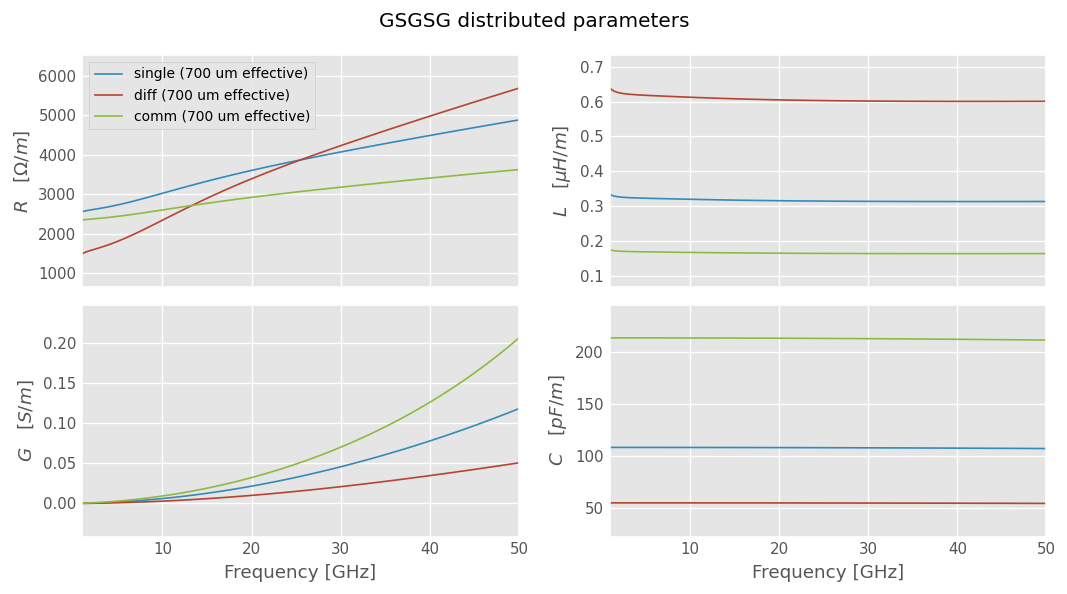

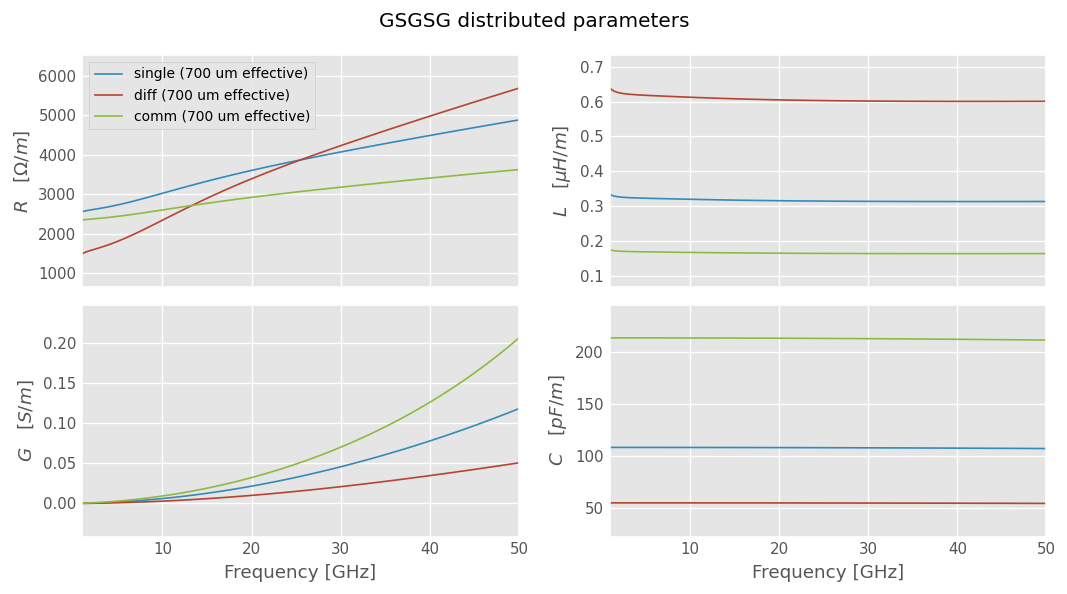

In [21]:
plot_rlgc(
    [
        (
            f"{mode} (700 um effective)",
            deembedded[mode][700]["dut"],
            deembedded[mode][700],
            {},
        )
        for mode in ("single", "diff", "comm")
    ],
    "GSGSG distributed parameters",
)

## T-bar loaded electrode (MZM travelling-wave electrode)

A Mach-Zehnder modulator does not drive a bare transmission line. The modulator segments hang off the electrode as a periodic capacitive load, usually reached through **T-bars**: a stem out of the signal electrode ending in a cross arm, facing a mirrored T-bar from the ground, with the modulator capacitance across the remaining gap. This is a capacitively-loaded travelling-wave electrode (CL-TWE). The added shunt capacitance per unit length lowers $Z_c$ and raises $n_{\mathrm{eff}}$ — which is the point, since matching $n_{\mathrm{eff}}$ to the optical group index is what sets the modulator's bandwidth.

Here a **pair** of facing T-bars sits in each signal-to-central-ground gap, in every period, on both halves of the structure. Two parameters are constrained rather than free:

- **`tbar_period` must divide every simulated length.** The P370 NZC fixture assumes a uniform line, so a fractional number of periods invalidates the de-embedding. For lengths of 100/400/800 µm that allows {10, 20, 25, 50} µm; 25 µm is used here, giving 4/16/32 periods and 12/28 periods for the de-embedded segments.
- **`tbar_gap` must stay at or above the mesh refinement size**, or the loading capacitance the section is about goes unresolved. At `refined_mesh_size=2.0` a 3 µm gap with 2 µm arms was found to mesh with a minimum element quality of 0.11, essentially matching the unloaded line's 0.13; a 2 µm gap or a 3 µm arm dropped it to 0.003–0.04, and *finer* refinement made it worse rather than better. Check `sim._last_mesh_result.mesh_stats["quality"]` if these are changed.

{'s_width': 20, 'g_width': 40, 'gap_width': 15, 'signal_pitch': 80, 'tbar_period': 25.0, 'tbar_gap': 3.0, 'n_periods': 4}


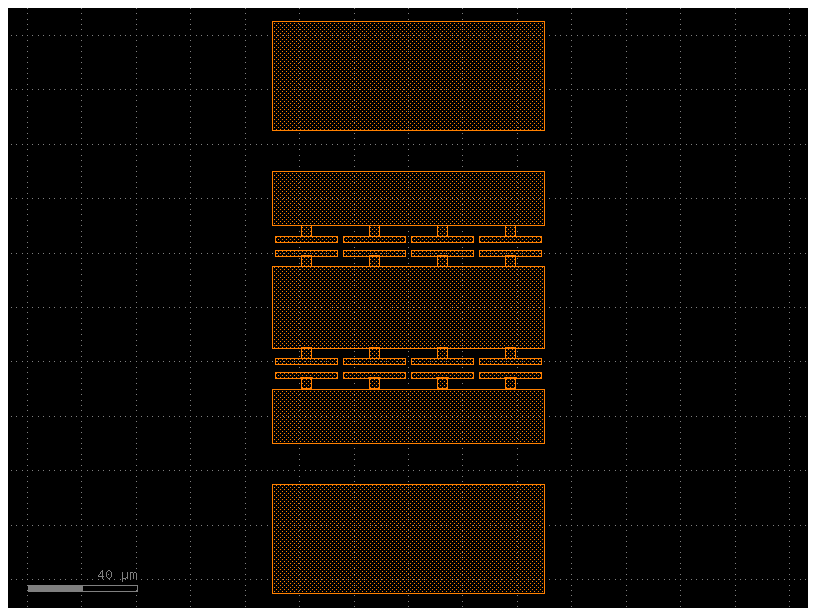

In [22]:
@gf.cell
def gsgsg_tbar_electrode(
    length: float = 800,
    s_width: float = 20,
    g_width: float = 40,
    gap_width: float = 15,
    signal_pitch: float = 80,
    tbar_period: float = 25.0,
    tbar_stem_width: float = 4.0,
    tbar_arm_length: float = 23.0,
    tbar_arm_width: float = 2.0,
    tbar_gap: float = 3.0,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """
    GSGSG electrode capacitively loaded with T-bars (MZM CL-TWE).

    In every period, each signal-to-central-ground gap carries a pair of facing
    T-bars: one grown from the signal electrode, one from the central ground,
    with their cross arms separated by `tbar_gap`.

    Args:
        length: horizontal length of the electrodes
        s_width: width of each signal electrode
        g_width: width of the two outer ground electrodes
        gap_width: gap between a signal electrode and its adjacent grounds
        signal_pitch: centre-to-centre spacing of the two signal electrodes
        tbar_period: longitudinal pitch of the T-bar pairs. Must divide every
            simulated length or the IEEE P370 de-embedding is invalid.
        tbar_stem_width: width of the T stem, along x
        tbar_arm_length: length of the T cross arm, along x
        tbar_arm_width: thickness of the T cross arm, along y
        tbar_gap: gap between the two facing cross arms. Keep at or above the
            refined mesh size or the loading capacitance is unresolved.
        layer: layer for the metal
    """
    c = gf.Component()
    base = c << gsgsg_electrode(
        length=length,
        s_width=s_width,
        g_width=g_width,
        gap_width=gap_width,
        signal_pitch=signal_pitch,
        layer=layer,
    )

    # Each T occupies (gap_width - tbar_gap) / 2 of the gap: stem, then arm.
    stem_length = (gap_width - tbar_gap) / 2 - tbar_arm_width
    if stem_length <= 0:
        raise ValueError(
            f"tbar_gap={tbar_gap} and tbar_arm_width={tbar_arm_width} leave no "
            f"room for a stem inside gap_width={gap_width}."
        )

    n_periods = round(length / tbar_period)
    if abs(n_periods * tbar_period - length) > 1e-9:
        raise ValueError(
            f"tbar_period={tbar_period} does not divide length={length}; a "
            "fractional number of periods breaks the P370 de-embedding."
        )

    s_inner = signal_pitch / 2 - s_width / 2  # signal edge facing the centre
    g_inner = s_inner - gap_width  # central ground edge

    x_centers = [-length / 2 + (i + 0.5) * tbar_period for i in range(n_periods)]

    for sign in (+1, -1):
        for x0 in x_centers:
            # T grown inward from the signal electrode, and its mirror grown
            # outward from the central ground.
            for y_root, direction in ((s_inner, -1), (g_inner, +1)):
                stem = c << gf.c.rectangle(
                    (tbar_stem_width, stem_length), centered=True, layer=layer
                )
                stem.move((x0, sign * (y_root + direction * stem_length / 2)))

                arm = c << gf.c.rectangle(
                    (tbar_arm_length, tbar_arm_width), centered=True, layer=layer
                )
                arm.move(
                    (
                        x0,
                        sign
                        * (y_root + direction * (stem_length + tbar_arm_width / 2)),
                    )
                )

    c.add_ports(base.ports)
    c.info["s_width"] = s_width
    c.info["g_width"] = g_width
    c.info["gap_width"] = gap_width
    c.info["signal_pitch"] = signal_pitch
    c.info["tbar_period"] = tbar_period
    c.info["tbar_gap"] = tbar_gap
    c.info["n_periods"] = n_periods
    return c


ct = gsgsg_tbar_electrode(length=100)
print(dict(ct.info))
ct

In [23]:
tbar100 = gsgsg_tbar_electrode(length=100)
tbar400 = gsgsg_tbar_electrode(length=400)

tbar_raw = []
for lc in [tbar100, tbar400]:
    sim = setup_sim(lc, output_dir="./palace-sim-gsgsg-tbar")
    sim.mesh(preset="default", refined_mesh_size=2.000, max_mesh_size=40.0, fmax=60e9, auto_size=True)
    stats = sim._last_mesh_result.mesh_stats
    print(
        f"length={lc.info['n_periods'] * lc.info['tbar_period']:5.0f} um  "
        f"nodes={stats['nodes']:6d}  min quality={stats['quality']['min']:.3f}  "
        f"invalid={stats['sicn']['invalid']}"
    )
    tbar_raw.append(sim.run(wait=False, check_cache=True))

Validation: PASSED
length=  100 um  nodes= 17326  min quality=0.031  invalid=0
Job started: palace-8a6c7256
Validation: PASSED
length=  400 um  nodes= 43273  min quality=0.031  invalid=0
Job started: palace-2afc2c4b


In [24]:
tbar_raw = gsim.wait_for_results(tbar_raw)

Waiting for 2 jobs...
  palace-8a6c7256                [####################] 100% complete     elapsed 6m 21s
  palace-2afc2c4b                [####################] 100% complete     elapsed 14m 02s
Extracting results.tar.gz...
Downloaded 9 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-8a6c7256
Extracting results.tar.gz...
Downloaded 9 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-2afc2c4b


In [25]:
tbar_mm = [to_mixed_mode(r) for r in tbar_raw]

tbar_deembedded = {}
for mode in ("single", "diff", "comm"):
    tbar_deembedded[mode] = {
        300: p370_extract(tbar_mm[0][mode], tbar_mm[1][mode], delta_length_m=300e-6),
        #700: p370_extract(tbar_mm[0][mode], tbar_mm[2][mode], delta_length_m=700e-6),
    }

for mode in ("single", "diff", "comm"):
    unloaded = deembedded[mode][300]
    loaded = tbar_deembedded[mode][300]
    print(
        f"{mode:7s} Zc {np.median(unloaded['zc'].real):6.2f} -> "
        f"{np.median(loaded['zc'].real):6.2f} ohm    "
        f"neff {np.nanmedian(unloaded['neff']):5.3f} -> "
        f"{np.nanmedian(loaded['neff']):5.3f}"
    )

single  Zc  53.99 ->  39.77 ohm    neff 1.744 -> 2.319
diff    Zc 105.23 ->  77.01 ohm    neff 1.719 -> 2.296
comm    Zc  27.76 ->  20.57 ohm    neff 1.772 -> 2.344


### Loaded vs unloaded

Both extractions use the 400 µm de-embedded segment, so the port parasitics are removed from each and the comparison isolates the effect of the T-bars.

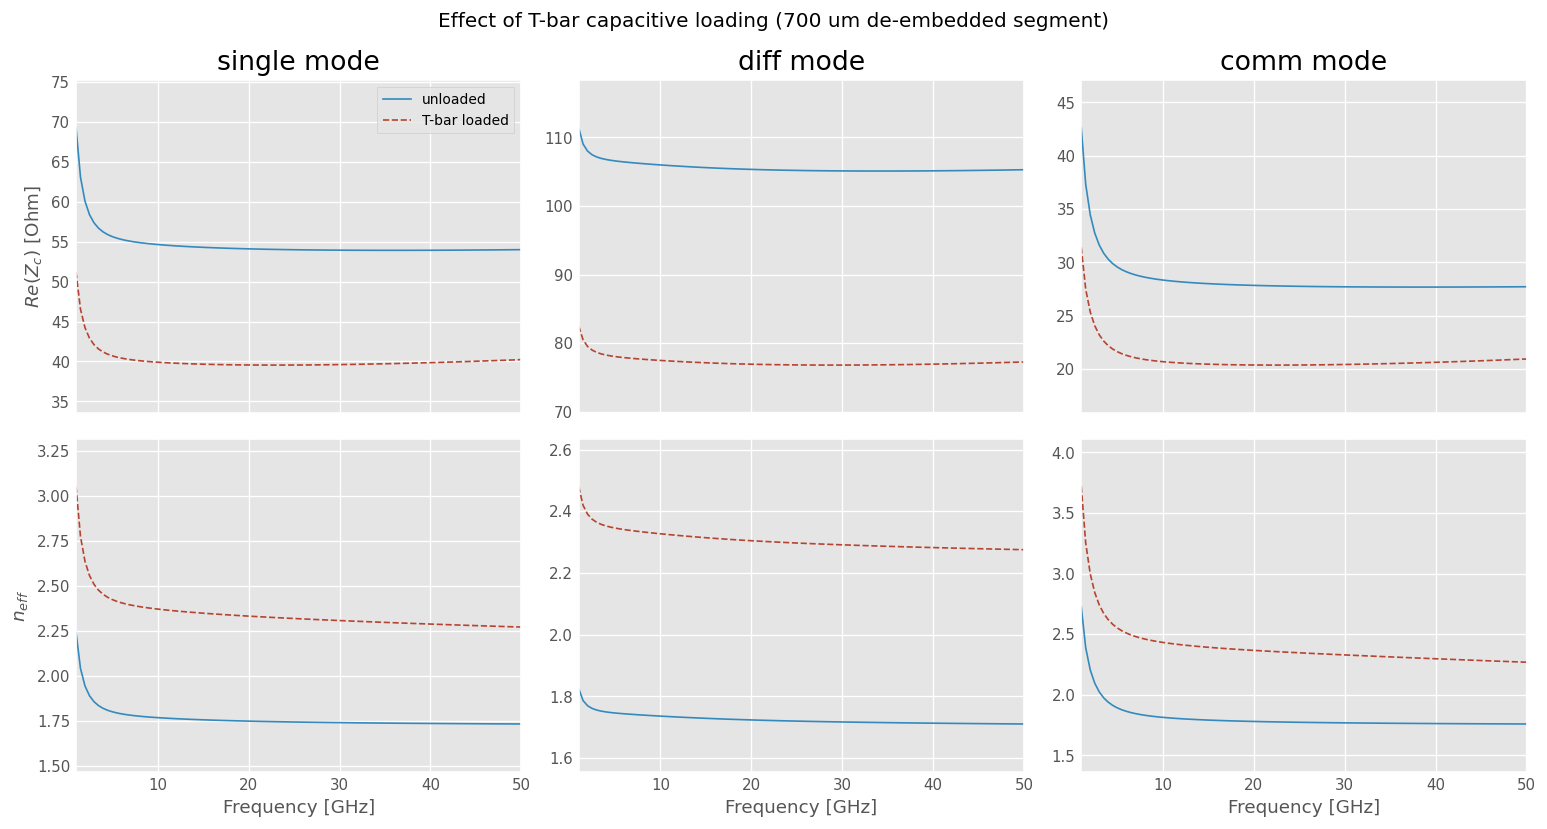

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=3, sharex=True, figsize=(13, 7))

for col, mode in enumerate(("single", "diff", "comm")):
    unloaded = deembedded[mode][300]
    loaded = tbar_deembedded[mode][300]
    freq_scaled = unloaded["dut"].frequency.f_scaled

    axes[0, col].plot(freq_scaled, unloaded["zc"].real, label="unloaded")
    axes[0, col].plot(freq_scaled, loaded["zc"].real, "--", label="T-bar loaded")
    axes[0, col].set_title(f"{mode} mode")

    axes[1, col].plot(freq_scaled, unloaded["neff"].real, label="unloaded")
    axes[1, col].plot(freq_scaled, loaded["neff"].real, "--", label="T-bar loaded")
    axes[1, col].set_xlabel(f"Frequency [{unloaded['dut'].frequency.unit}]")

axes[0, 0].set_ylabel(r"$Re(Z_c)$ [Ohm]")
axes[1, 0].set_ylabel(r"$n_{eff}$")
axes[0, 0].legend(fontsize="small")
fig.suptitle("Effect of T-bar capacitive loading (700 um de-embedded segment)")
plt.tight_layout()

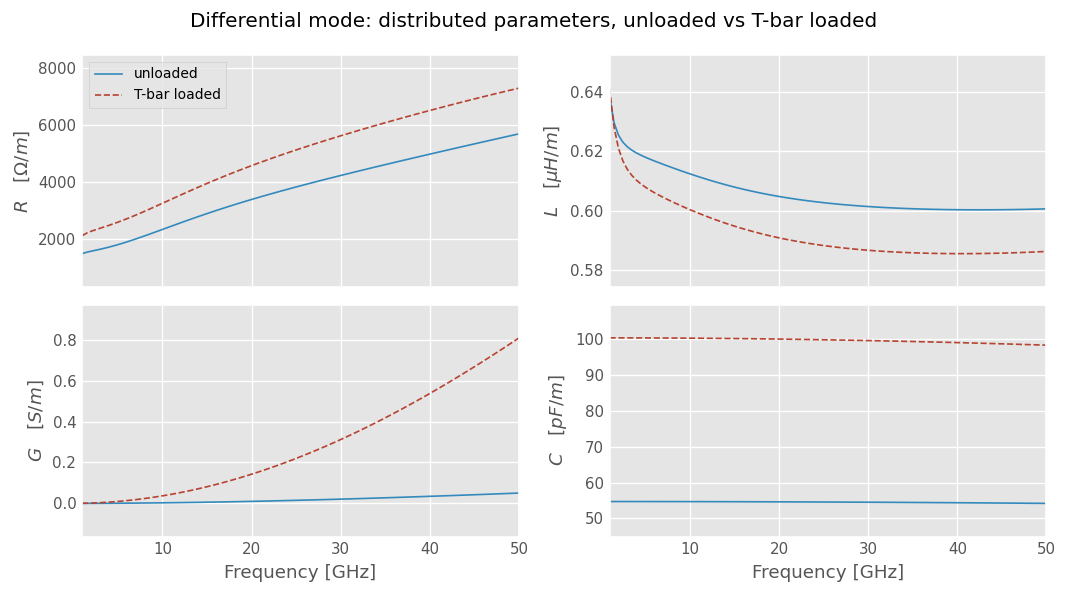

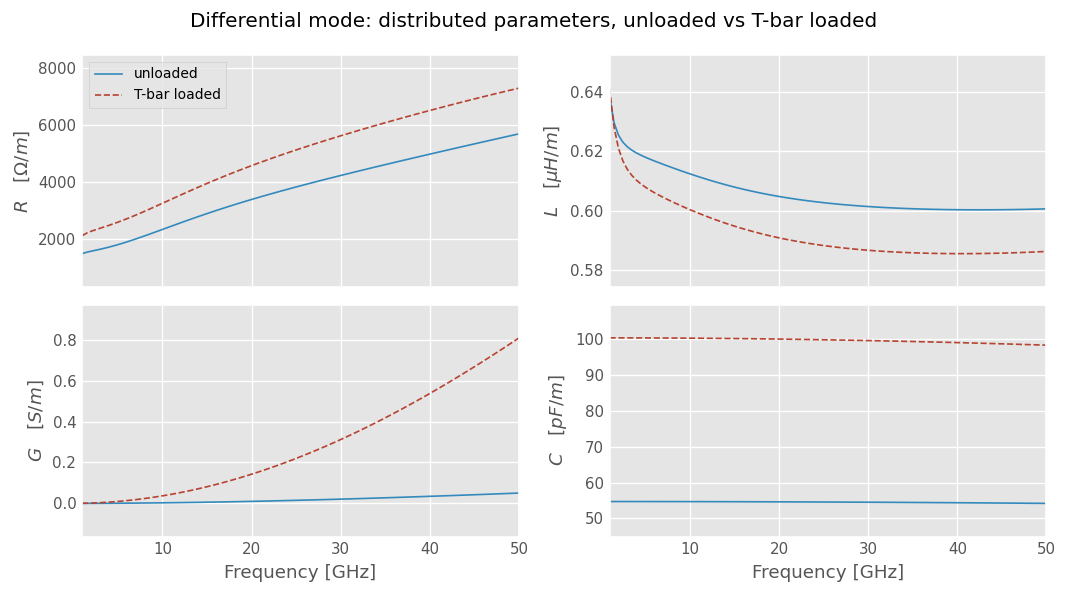

In [27]:
plot_rlgc(
    [
        ("unloaded", deembedded["diff"][300]["dut"], deembedded["diff"][700], {}),
        (
            "T-bar loaded",
            tbar_deembedded["diff"][300]["dut"],
            tbar_deembedded["diff"][300],
            {"linestyle": "--"},
        ),
    ],
    "Differential mode: distributed parameters, unloaded vs T-bar loaded",
)

The loading shows up in the distributed parameters as an increase in $C$ with $L$ essentially unchanged, since the T-bars add shunt capacitance without altering the current path. That is the CL-TWE design lever: $Z_c = \sqrt{L/C}$ falls and $n_{\mathrm{eff}} \propto \sqrt{LC}$ rises, so period, arm length and gap can be traded off to hit both a 50 Ω match and velocity matching to the optical mode.

Note also that the differential and common modes no longer track each other the way they did on the bare line: the T-bars tie both signal electrodes to the same central ground, so the shared return path couples the two lines even though their 80 µm pitch leaves them decoupled when unloaded. The residual-coupling metrics plotted earlier are worth re-running on the loaded structure for that reason.

## Twelve-port 100 µm MZM section

The distributed model above treats each T-bar pair as a metal loading structure. For a circuit-level MZM model we instead need access to the electrical node at every pair so that the junction RC network and electro-optic post-processing can be added later. This section puts one horizontal **in-plane lumped port** across each facing pair of T-bars. Each port spans the full 10 µm overlap of the cross arms and the 3 µm gap between them. A 100 µm section at 25 µm pitch therefore has four local ports on the upper arm and four on the lower arm, in addition to the four end wave ports: a complete 12-port network.

Every port is excited because the circuit simulator needs the complete matrix, including coupling between T-bars and between arms. The eight local ports are named `upper_tbar_1` … `upper_tbar_4` and `lower_tbar_1` … `lower_tbar_4`, ordered from left to right. Their positive direction points from the signal T-bar toward the shared central ground.

The IEEE P370 split made above cannot be applied verbatim: each half-fixture contains both the wave-port discontinuity **and 50 µm of the 100 µm 2x-thru**. Removing the complete fixture from another 100 µm model would also remove its electrical length. We therefore synthesize that 50 µm loaded-line section from the previously extracted $Z_c$ and $\gamma$, remove it from each differential- and common-mode half-fixture, and transform the remaining modal error boxes back into coupled four-port fixtures. Applying their inverses only to the four boundary ports preserves the full 100 µm section and leaves the eight internal ports untouched.

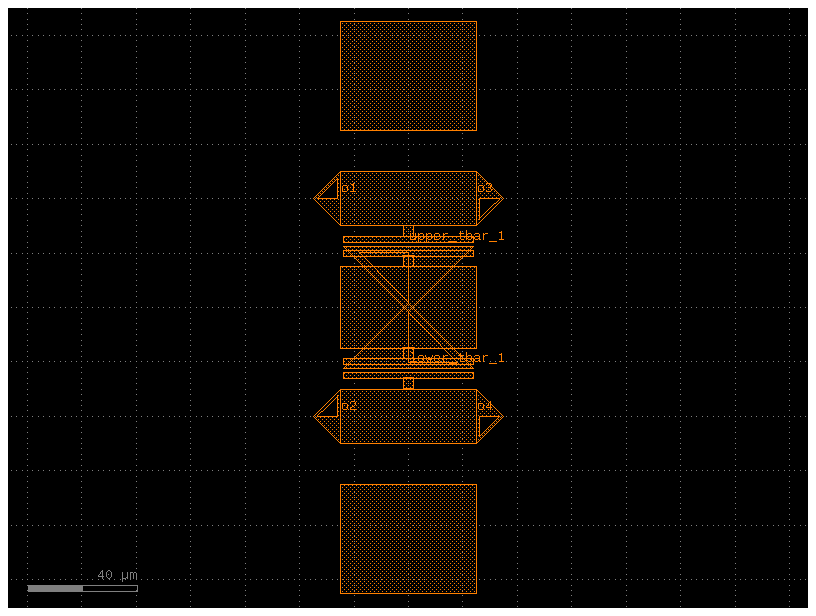

In [ ]:
n_periods=1
TBAR_LUMPED_PORT_NAMES = tuple(
    [f"upper_tbar_{i}" for i in range(1, n_periods+1)]
    + [f"lower_tbar_{i}" for i in range(1, n_periods+1)]
)


@gf.cell
def gsgsg_tbar_lumped_segment(
    length: float = 50.0,
    tbar_period: float = 50.0,
    s_width: float = 20.0,
    g_width: float = 40.0,
    gap_width: float = 15.0,
    signal_pitch: float = 80.0,
    tbar_stem_width: float = 4.0,
    tbar_arm_length: float = 48.0,
    tbar_arm_width: float = 2.0,
    tbar_gap: float = 3.0,
    layer=LAYER.TopMetal2drawing,
) -> gf.Component:
    """T-bar-loaded GSGSG section with a gap port at every T-bar pair."""
    n_periods = round(length / tbar_period)



    # if n_periods != 4 or not np.isclose(n_periods * tbar_period, length):
    #     raise ValueError(
    #         "This circuit segment must contain exactly four complete T-bar periods."
    #     )

    c = gf.Component()
    base = c << gsgsg_tbar_electrode(
        length=length,
        s_width=s_width,
        g_width=g_width,
        gap_width=gap_width,
        signal_pitch=signal_pitch,
        tbar_period=tbar_period,
        tbar_stem_width=tbar_stem_width,
        tbar_arm_length=tbar_arm_length,
        tbar_arm_width=tbar_arm_width,
        tbar_gap=tbar_gap,
        layer=layer,
    )
    c.add_ports(base.ports)

    stem_length = (gap_width - tbar_gap) / 2 - tbar_arm_width
    s_inner = signal_pitch / 2 - s_width / 2
    gap_center_from_axis = (
        s_inner - stem_length - tbar_arm_width - tbar_gap / 2
    )
    x_centers = [
        -length / 2 + (i + 0.5) * tbar_period for i in range(n_periods)
    ]

    for arm, sign, orientation in (
        ("upper", +1, 270),
        ("lower", -1, 90),
    ):
        for i, x0 in enumerate(x_centers, start=1):
            c.add_port(
                name=f"{arm}_tbar_{i}",
                center=(x0, sign * gap_center_from_axis),
                width=tbar_arm_length,
                orientation=orientation,
                port_type="electrical",
                layer=layer,
            )

    for key, value in (
        ("s_width", s_width),
        ("g_width", g_width),
        ("gap_width", gap_width),
        ("signal_pitch", signal_pitch),
        ("tbar_period", tbar_period),/tmp/oa-migrate-live-smoke/oa_parameters.json
        ("tbar_gap", tbar_gap),
        ("n_periods", n_periods),
    ):
        c.info[key] = value
    return c


mzm_segment = gsgsg_tbar_lumped_segment()
mzm_segment_display = mzm_segment.copy()
mzm_segment_display.draw_ports()
mzm_segment_display

In [29]:
def setup_mzm_segment_sim(cell):
    sim = setup_sim(cell, output_dir="./palace-sim-gsgsg-tbar-lumped-100um")
    for name in TBAR_LUMPED_PORT_NAMES:
        sim.add_port(
            name,
            geometry="inplane",
            layer="topmetal2",
            length=cell.info["tbar_gap"],
            impedance=50.0,
            excited=True,
        )
    print(sim.validate_config())
    return sim


mzm_sim = setup_mzm_segment_sim(mzm_segment)
mzm_sim.mesh(
    preset="default", refined_mesh_size=2.0, max_mesh_size=40.0, fmax=60e9
)
print(
    f"ports={len(mzm_sim._last_mesh_result.port_info)}  "
    f"min quality={mzm_sim._last_mesh_result.mesh_stats['quality']['min']:.3f}"
)

Small conductor feature detected (2.000 um) may be under-resolved by refined_mesh_size=5.000 um. Pass auto_size=True to scale the mesh down.


Validation: PASSED
Validation: PASSED
ports=6  min quality=0.126


In [30]:
job_id = mzm_sim.run(check_cache=True, wait=False)

Info    : Reading 'palace-sim-gsgsg-tbar-lumped-100um/palace.msh'...
Info    : 12633 nodes
Info    : 76300 elements
Info    : Done reading 'palace-sim-gsgsg-tbar-lumped-100um/palace.msh'
Info    : Reading 'palace-sim-gsgsg-tbar-lumped-100um/palace.msh'...
Info    : 12633 nodes
Info    : 76300 elements
Info    : Done reading 'palace-sim-gsgsg-tbar-lumped-100um/palace.msh'
Job started: palace-39f36a61


In [31]:
job_id

'01a0d39b-587a-70b1-830a-cfc453432fd0'

In [32]:
mzm_raw = gsim.wait_for_results(job_id)

  palace-39f36a61  [####################] 100%  complete  elapsed 7m 00s
Extracting results.tar.gz...
Downloaded 11 files to /home/cdaunt/code/gdsfactory/gsim/nbs/sim-data-palace-39f36a61


In [33]:
from skrf.network import a2s, connect


def uniform_line_network(template, params, length_m, name):
    """Build a line with the extracted Zc/gamma and template reference Z0."""
    gamma_l = params["gamma"] * length_m
    cosh_gl = np.cosh(gamma_l)
    sinh_gl = np.sinh(gamma_l)
    abcd = np.empty((len(template), 2, 2), dtype=complex)
    abcd[:, 0, 0] = cosh_gl
    abcd[:, 0, 1] = params["zc"] * sinh_gl
    abcd[:, 1, 0] = sinh_gl / params["zc"]
    abcd[:, 1, 1] = cosh_gl
    line = rf.Network(
        frequency=template.frequency.copy(),
        s=a2s(abcd, z0=template.z0),
        z0=template.z0.copy(),
        name=name,
    )
    line.port_names = ["left", "right"]
    return line


def port_only_error_boxes(p370_result, thru_length_m=100e-6):
    """Remove the half-thru line delay from the two P370 error boxes."""
    half_line = uniform_line_network(
        p370_result["dut"],
        p370_result,
        thru_length_m / 2,
        name="50 um loaded line",
    )
    split = p370_result["deembedding"]

    # Raw topology is: left_error ** line ** DUT ** line ** right_error.
    left_full = split.s_side1
    right_full = split.s_side2.flipped()
    left_port_error = left_full ** half_line.inv
    right_port_error = half_line.inv ** right_full
    return left_port_error, right_port_error


def modal_pair_to_single_ended(diff_error, comm_error, name):
    """Combine differential/common 2-ports into one GSGSG 4-port fixture."""
    if diff_error.frequency != comm_error.frequency:
        raise ValueError("Differential and common fixtures need the same sweep.")

    s_mm = np.zeros((len(diff_error), 4, 4), dtype=complex)
    s_mm[:, :2, :2] = diff_error.s
    s_mm[:, 2:, 2:] = comm_error.s
    fixture = rf.Network(
        frequency=diff_error.frequency.copy(),
        s=s_mm,
        z0=np.concatenate((diff_error.z0, comm_error.z0), axis=1),
        name=name,
    )
    # Mixed-mode order [d_ext, d_int, c_ext, c_int] becomes
    # single-ended [upper_ext, lower_ext, upper_int, lower_int].
    fixture.gmm2se(p=2)
    return fixture


def deembed_boundary_ports(net, left_error, right_error):
    """De-embed two coupled end-port pairs and retain every local port."""
    out = net.copy()

    left_inverse = left_error.inv
    left_inverse.port_names = ["o1", "o2", "__o1_inside", "__o2_inside"]
    left_raw_port = list(out.port_names).index("o1")
    if list(out.port_names)[left_raw_port : left_raw_port + 2] != ["o1", "o2"]:
        raise ValueError("The left wave-port pair must be consecutive.")
    out = connect(left_inverse, 2, out, left_raw_port, num=2)

    right_inverse = right_error.inv
    right_inverse.port_names = ["__o3_inside", "__o4_inside", "o3", "o4"]
    right_raw_port = list(out.port_names).index("o3")
    if list(out.port_names)[right_raw_port : right_raw_port + 2] != ["o3", "o4"]:
        raise ValueError("The right wave-port pair must be consecutive.")
    out = connect(out, right_raw_port, right_inverse, 0, num=2)

    desired_order = list(PORT_NAMES) + list(TBAR_LUMPED_PORT_NAMES)
    current_order = list(out.port_names)
    if set(current_order) != set(desired_order):
        raise ValueError(
            f"Expected ports {desired_order}, got {current_order} after de-embedding."
        )
    out.renumber(
        [current_order.index(name) for name in desired_order],
        range(len(desired_order)),
    )
    out.name = "100 um T-bar MZM section, wave ports de-embedded"
    return out


# Reuse both loaded-line modal P370 splits, then return to the single-ended
# basis needed by the 12-port circuit model. Symmetry makes mode conversion
# zero in each boundary fixture, while diff/common behavior can still differ.
modal_port_errors = {
    mode: port_only_error_boxes(tbar_deembedded[mode][300])
    for mode in ("diff", "comm")
}
left_port_error = modal_pair_to_single_ended(
    modal_port_errors["diff"][0],
    modal_port_errors["comm"][0],
    name="left wave-port error box",
)
right_port_error = modal_pair_to_single_ended(
    modal_port_errors["diff"][1],
    modal_port_errors["comm"][1],
    name="right wave-port error box",
)

6-port network
P 1: o1
P 2: o2
P 3: o3
P 4: o4
P 5: upper_tbar_1
P 6: lower_tbar_1


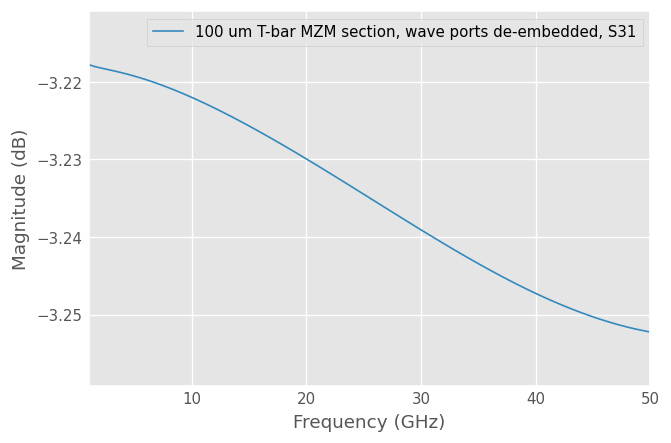

In [38]:
mzm_raw_network = mzm_raw.to_skrf()
mzm_raw_network.frequency.unit = "GHz"
mzm_100um_deembedded = deembed_boundary_ports(
    mzm_raw_network, left_port_error, right_port_error
)

print(f"{mzm_100um_deembedded.nports}-port network")
for number, name in enumerate(mzm_100um_deembedded.port_names, start=1):
    print(f"P{number:2d}: {name}")
mzm_100um_deembedded.plot_s_db(2,0)

`mzm_100um_deembedded` is the circuit-ready network. Ports 1–4 are the RF line ends; ports 5–8 are the four upper-arm junction sites; and ports 9–12 are the four lower-arm junction sites. The following optional export writes a 12-port Touchstone file with the port names embedded as comments. The circuit model can connect one RC network to each T-bar port and leave the four travelling-wave ports as the external RF terminals.

In [39]:
mzm_100um_deembedded.write_touchstone(
    "mzm_tbar_100um_12port_deembedded", form="ri", write_z0=True
)

## Junction RC loading of the Palace MZM section (SAX)

Run this section **after `mzm_raw = mzm_sim.run(...)` finishes**. It uses the existing result; it never meshes, submits, or waits for a Palace job. You can jump here directly from that result cell: the preceding de-embedding/export cells are not required.

Following the electrical junction model in [the proposal 2 SAX notebook](../../neurophos/nbs/rf_circuit/sax/sax_proposal2_multiport_analysis.ipynb), each local port is terminated by

$$Z_{\mathrm{load}}(f)=R_s+\left(R_j^{-1}+j2\pi fC_j\right)^{-1}.$$

Topology: **Palace gap port → series $R_s$ → junction node → $R_j\parallel C_j$ → local return**. The gap port already represents the voltage across the signal/ground T-bars; no additional ground port or fan-out tee is needed. Both arms remain coupled through the full Palace S-matrix. After terminating all local ports, the external order is `[o1, o2, o3, o4]` = `[upper left, lower left, upper right, lower right]`.

The bias table below is copied from the proposal as an **example**, not a calibrated IHP junction model. Resistance scales inversely with junction length; capacitance scales with length. The default length is read from the geometry (`n_periods * tbar_period`) rather than the output-directory name: the currently saved function defaults describe **50 µm with one local port per arm**, although the earlier prose says 100 µm / twelve ports. Set `RC_ACTIVE_LENGTH_M` to the actual active junction length per arm for your completed run (100e-6 for a 100 µm active section).

This section defaults to the raw result, including wave-port discontinuities. A validated de-embedded network can be selected explicitly below; the earlier fixture cells currently reference a 700 µm extraction that is not generated by the saved two-length sweep. This is the electrical RC-loaded unit cell only; optical VCVS accumulators, optical walk-off, and cascades from the reference notebook are not included.

In [40]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import sax
import skrf as rf

jax.config.update("jax_enable_x64", True)

RC_Z0 = 50.0
RC_RF_PORTS = ("o1", "o2", "o3", "o4")
if "mzm_raw" not in globals() or not hasattr(mzm_raw, "to_skrf"):
    raise RuntimeError("Wait for the existing mzm_raw simulation cell to finish first.")
rc_em = mzm_raw.to_skrf(z0=RC_Z0)
# Optional, only after validating the fixture extraction and port names:
# rc_em = mzm_100um_deembedded.copy()
rc_em.renormalize(RC_Z0)
rc_em.frequency.unit = "GHz"

rc_names = list(rc_em.port_names or [])
rc_arm_ports = {
    arm: sorted(
        (p for p in rc_names if p.startswith(f"{arm}_tbar_")),
        key=lambda p: int(p.rsplit("_", 1)[1]),
    )
    for arm in ("upper", "lower")
}
rc_local_ports = rc_arm_ports["upper"] + rc_arm_ports["lower"]
if (
    len(set(rc_names)) != rc_em.nports
    or set(rc_names) != set(RC_RF_PORTS) | set(rc_local_ports)
    or not all(rc_arm_ports.values())
):
    raise ValueError(f"Expected named RF and upper/lower T-bar ports, got {rc_names}.")
if not np.all(np.isfinite(rc_em.s)) or np.any(np.diff(rc_em.f) <= 0):
    raise ValueError("The completed Palace sweep must be finite and increasing.")
print("RC loading:", rc_arm_ports)

RC_BIAS_V = -1
RC_ACTIVE_LENGTH_M = (
    float(mzm_segment.info["n_periods"])
    * float(mzm_segment.info["tbar_period"]) * 1e-6
)
RC_BIAS_TABLE = {
    0: {"r_dc": 10000.0, "cj_per_m": 0.85 * 250e-12},
    -1: {"r_dc": 10000.0, "cj_per_m": 0.85 * 225e-12},
    -2: {"r_dc": 10000.0, "cj_per_m": 0.85 * 210e-12},
    -3: {"r_dc": 10000.0, "cj_per_m": 0.85 * 190e-12},
}
rc_cfg = RC_BIAS_TABLE[RC_BIAS_V]
rc_rs_length = 8.9e-3  # ohm*m
rc_rj_length = (rc_cfg["r_dc"] - rc_rs_length / 100e-6) * 100e-6
if RC_ACTIVE_LENGTH_M <= 0:
    raise ValueError("RC_ACTIVE_LENGTH_M must be positive.")
rc_settings = {}
for arm, ports in rc_arm_ports.items():
    site_length = RC_ACTIVE_LENGTH_M / len(ports)
    for port in ports:
        rc_settings[port] = {
            "rs": rc_rs_length / site_length,
            "rj": rc_rj_length / site_length,
            "cj": rc_cfg["cj_per_m"] * site_length,
        }
    print(f"{arm}: active length = {RC_ACTIVE_LENGTH_M * 1e6:g} um, "
          f"length/site = {site_length * 1e6:g} um, {rc_settings[ports[0]]}")
# Edit rc_settings[port] here to model unequal junctions on the two arms.

RC loading: {'upper': ['upper_tbar_1'], 'lower': ['lower_tbar_1']}
upper: active length = 50 um, length/site = 50 um, {'rs': 178.0, 'rj': 19822.000000000004, 'cj': 9.562499999999999e-15}
lower: active length = 50 um, length/site = 50 um, {'rs': 178.0, 'rj': 19822.000000000004, 'cj': 9.562499999999999e-15}


In [ ]:
def rc_series_resistor(*, r=50.0):
    reflection = r / (r + 2 * RC_Z0)
    transmission = 2 * RC_Z0 / (r + 2 * RC_Z0)
    return {("a", "a"): reflection, ("b", "b"): reflection,
            ("a", "b"): transmission, ("b", "a"): transmission}


def rc_junction(*, frequency=1e9, rj=1e4, cj=1e-15):
    y = 1 / rj + 2j * jnp.pi * jnp.asarray(frequency) * cj
    return {("p", "p"): (1 - RC_Z0 * y) / (1 + RC_Z0 * y)}


rc_instances = {"palace": {"component": "palace"}}
rc_connections = {}
for port, values in rc_settings.items():
    rc_instances[f"rs_{port}"] = {
        "component": "rs", "settings": {"r": values["rs"]}
    }
    rc_instances[f"junction_{port}"] = {
        "component": "junction",
        "settings": {"rj": values["rj"], "cj": values["cj"]},
    }
    rc_connections[f"palace,{port}"] = f"rs_{port},a"
    rc_connections[f"rs_{port},b"] = f"junction_{port},p"
plot_it_all
rc_netlist = {
    "instances": rc_instances,
    "connections": rc_connections,
    "ports": {port: f"palace,{port}" for port in RC_RF_PORTS},
}
rc_circuit, _ = sax.circuit(
    netlist=rc_netlist,
    models={"palace": mzm_raw.to_sax(),
            "rs": rc_series_resistor, "junction": rc_junction},
)
rc_sdict = jax.block_until_ready(rc_circuit(frequency=jnp.asarray(rc_em.f)))
rc_s = np.stack([
    np.stack([np.asarray(rc_sdict[out_port, in_port])
              for in_port in RC_RF_PORTS], axis=-1)
    for out_port in RC_RF_PORTS
], axis=1)
mzm_rc_loaded = rf.Network(
    frequency=rc_em.frequency.copy(), s=rc_s, z0=RC_Z0,
    name="Palace MZM with junction RC loads",
)
mzm_rc_loaded.port_names = list(RC_RF_PORTS)
print(f"Loaded network: {mzm_rc_loaded.nports} external RF ports")

Loaded network: 4 external RF ports


### Verify the connections and compare with open junction ports

An independent block elimination checks SAX against
$S_\mathrm{loaded}=S_{ee}+S_{ei}\Gamma(I-S_{ii}\Gamma)^{-1}S_{ie}$,
where $\Gamma$ contains the RC load reflection coefficients. Setting $\Gamma=+I$ gives the **open local-port** baseline; simply taking a four-port submatrix would instead leave those ports matched to 50 Ω.

The plots compare RF through/return and differential/common-mode transmission. All unused external ports are matched to their reference impedances (50 Ω single-ended, 100 Ω differential, 25 Ω common mode). These are RF responses, not an EO bandwidth estimate.

SAX vs block termination max error: 1.29e-15


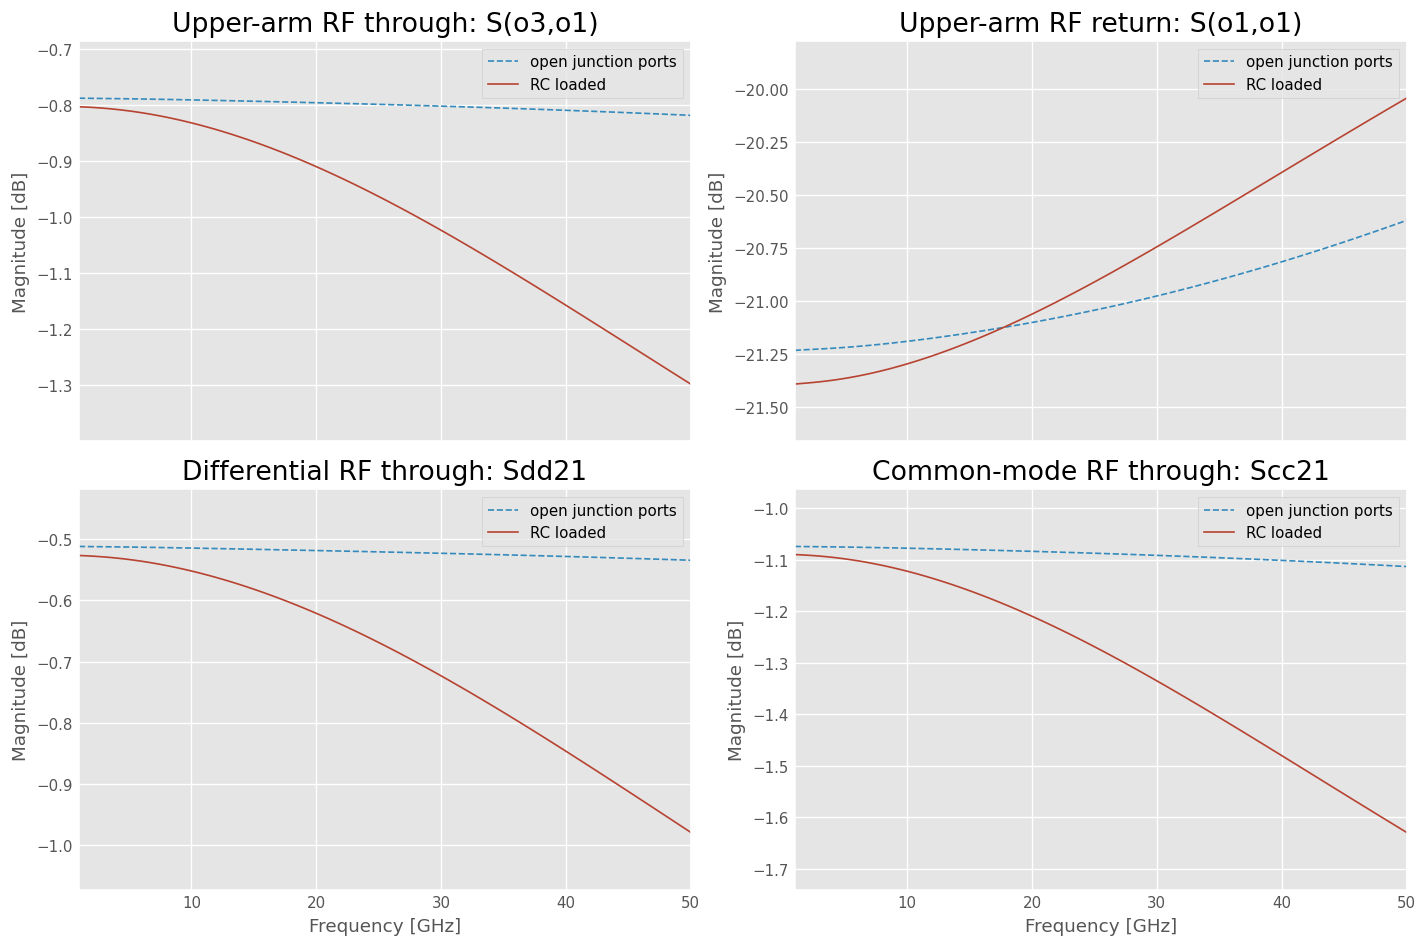

In [42]:
def rc_terminate_local_ports(net, gamma):
    external = [net.port_names.index(p) for p in RC_RF_PORTS]
    internal = [net.port_names.index(p) for p in rc_local_ports]
    s = net.s[:, external + internal][:, :, external + internal]
    see, sei = s[:, :4, :4], s[:, :4, 4:]
    sie, sii = s[:, 4:, :4], s[:, 4:, 4:]
    feedback = np.linalg.solve(
        np.eye(len(internal))[None, :, :] - sii * gamma[:, None, :], sie
    )
    return see + (sei * gamma[:, None, :]) @ feedback


rc_zloads = np.column_stack([
    values["rs"] + 1 / (1 / values["rj"] + 2j * np.pi * rc_em.f * values["cj"])
    for port in rc_local_ports
    for values in [rc_settings[port]]
])
rc_gamma = (rc_zloads - RC_Z0) / (rc_zloads + RC_Z0)
rc_direct = rc_terminate_local_ports(rc_em, rc_gamma)
np.testing.assert_allclose(mzm_rc_loaded.s, rc_direct, rtol=1e-8, atol=1e-10)
print(f"SAX vs block termination max error: {np.max(np.abs(rc_s - rc_direct)):.2e}")

mzm_rc_open = rf.Network(
    frequency=rc_em.frequency.copy(),
    s=rc_terminate_local_ports(rc_em, np.ones_like(rc_gamma)), z0=RC_Z0,
    name="Open local ports",
)
mzm_rc_open.port_names = list(RC_RF_PORTS)
rc_fig, rc_axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for network, label, style in (
    (mzm_rc_open, "open junction ports", "--"),
    (mzm_rc_loaded, "RC loaded", "-"),
):
    mm = network.copy()
    mm.se2gmm(p=2)
    for ax, response, title in (
        (rc_axes[0, 0], network.s[:, 2, 0], "Upper-arm RF through: S(o3,o1)"),
        (rc_axes[0, 1], network.s[:, 0, 0], "Upper-arm RF return: S(o1,o1)"),
        (rc_axes[1, 0], mm.s[:, 1, 0], "Differential RF through: Sdd21"),
        (rc_axes[1, 1], mm.s[:, 3, 2], "Common-mode RF through: Scc21"),
    ):
        ax.plot(network.f / 1e9, 20 * np.log10(np.maximum(np.abs(response), 1e-15)),
                style, label=label)
        ax.set(title=title, ylabel="Magnitude [dB]")
        ax.grid(True)
        ax.legend()
for ax in rc_axes[1]:
    ax.set_xlabel("Frequency [GHz]")
rc_fig.tight_layout()
# Optional export after reviewing the junction parameters:
# mzm_rc_loaded.write_touchstone("mzm_rc_loaded_4port", form="ri", write_z0=True)